In [49]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils import *
from utils_sofima import *
import numpy as np
import hyperspy.api as hs
import matplotlib.pyplot as plt
import copy
from importlib import reload
from EDX import *
from skimage import data, img_as_float, feature
import tensorstore as ts
from scipy.stats import pearsonr
from datetime import datetime
import warnings
import pickle
from datetime import datetime

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load haadf stack

In [4]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# load and preprocess
_, haadf_stack, _ = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True, haadf_last_frame=False)

print(haadf_stack.shape)
print(haadf_stack.max(),haadf_stack.dtype)

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
(100, 2048, 2048)
65535.0 float64


### Align based on the first 20 HAADf images 

In [ ]:
sof_obj = get_alignment(haadf_stack, 
                  n_align = 3,
                  min_peak_ratio=1.1, 
                  min_peak_sharpness=1.1,
                  max_magnitude=0, 
                  max_deviation=0,
                  patch_size = 100,
                  stride = 25,
                  pad_remove = 50)

print(sof_obj.inv_map.shape)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

### Save the transformation

In [42]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"results/sofima_transforms/{timestamp}_sof_object.pkl", "wb") as f:
    pickle.dump(sof_obj, f)


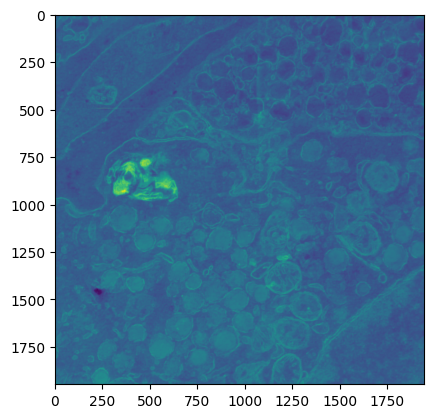

In [44]:
plt.imshow(sof_obj.transformation[:,:,0])